# Food Waste Predictor: End-to-End Notebook

This notebook walks you through an end-to-end ML workflow for predicting food waste in a university canteen using a real-world dataset.
Each code line has an inline comment explaining what it does and why it is needed.


In [1]:
# Step 1: Import all the libraries we need
import pandas as pd  # for data manipulation (tables)
import numpy as np  # for numerical operations
import matplotlib.pyplot as plt  # for basic plotting
import seaborn as sns  # for statistical plots
from IPython.display import display  # to display tables nicely in notebook
from sklearn.model_selection import train_test_split  # to split data into train and test
from sklearn.preprocessing import StandardScaler  # to scale features for linear models
from sklearn.pipeline import Pipeline  # to chain preprocessing steps together
from sklearn.linear_model import LinearRegression  # simple baseline model
from sklearn.tree import DecisionTreeRegressor  # non-linear model (tree-based)
from sklearn.ensemble import RandomForestRegressor  # robust ensemble model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # for evaluation
import joblib  # to save and load models


## STEP 2: Load and Understand Data

We load the dataset and inspect its shape, columns, and first few rows to understand what features we have.


In [4]:
# Step 2: Load the dataset from the data folder
df = pd.read_csv(r"C:\Users\Srevarshan\OneDrive\Desktop\Projects\Data Science Mini\data\food_waste.csv")  # read the CSV file into a table

# Show basic information about the data
print("Dataset Shape:", df.shape)  # number of rows and columns
print("\nColumn Names:", df.columns.tolist())  # list of all column names
print("\nFirst 5 Rows:")
display(df.head())  # display the first few rows nicely
print("\nData Types:")
print(df.dtypes)  # show what type of data is in each column


Dataset Shape: (2600, 7)

Column Names: ['Date', 'Meal', 'Canteen_Section', 'Food_Category', 'Waste_Weight_kg', 'Unit_Price_per_kg', 'Cost_Loss']

First 5 Rows:


,Date,Meal,Canteen_Section,Food_Category,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss
0,2025-07-30,Dinner,B,Vegetables,1.50,3.0,4.50
1,2025-06-15,Breakfast,B,Rice,3.69,2.0,7.38
2,2025-07-29,Breakfast,A,Soup,1.54,1.5,2.31
3,2025-07-17,Breakfast,A,Soup,1.81,1.5,2.71
4,2025-07-03,Dinner,D,Rice,4.69,2.0,9.38



Data Types:
Date                     str
Meal                     str
Canteen_Section          str
Food_Category            str
Waste_Weight_kg      float64
Unit_Price_per_kg    float64
Cost_Loss            float64
dtype: object


### Column Meanings (Simple Glossary)

- **Date**: The day when the observation was recorded (YYYY-MM-DD)
- **Meal**: Type of meal (Breakfast, Lunch, Dinner)
- **Canteen_Section**: Which section of the canteen (A, B, C, D)
- **Food_Category**: Type of food (Rice, Soup, Vegetables, Meat, etc.)
- **Waste_Weight_kg**: Amount of food wasted in kilograms (**THIS IS OUR TARGET - what we want to predict**)
- **Unit_Price_per_kg**: Price per kilogram of food
- **Cost_Loss**: Total cost of wasted food (Waste_Weight_kg × Unit_Price_per_kg)


## STEP 3: Clean Data

We prepare the data for modeling by:
- Removing duplicate rows
- Handling missing values
- Converting date to proper format and extracting useful time features (month, day of week)


In [5]:
# Step 3: Clean the data
df_clean = df.copy()  # make a copy so we don't change the original data

# 3a) Remove duplicate rows (same data repeated)
df_clean = df_clean.drop_duplicates()

# 3b) Check for missing values
print("Missing values before cleaning:")
print(df_clean.isnull().sum())

# 3c) Fill missing numeric values with median (middle value - robust to outliers)
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# 3d) Fill missing text values with most common value
text_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
for col in text_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# 3e) Convert Date to datetime and extract useful features
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')  # convert to date format
df_clean['Year'] = df_clean['Date'].dt.year  # extract year
df_clean['Month'] = df_clean['Date'].dt.month  # extract month (1-12)
df_clean['Day'] = df_clean['Date'].dt.day  # extract day of month
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek  # 0=Monday, 6=Sunday

# 3f) Create a weekend flag (1 for Saturday/Sunday, 0 otherwise)
df_clean['IsWeekend'] = df_clean['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())
print("\nCleaned data shape:", df_clean.shape)


Missing values before cleaning:
Date                 0
Meal                 0
Canteen_Section      0
Food_Category        0
Waste_Weight_kg      0
Unit_Price_per_kg    0
Cost_Loss            0
dtype: int64

Missing values after cleaning:
Date                 0
Meal                 0
Canteen_Section      0
Food_Category        0
Waste_Weight_kg      0
Unit_Price_per_kg    0
Cost_Loss            0
Year                 0
Month                0
Day                  0
DayOfWeek            0
IsWeekend            0
dtype: int64

Cleaned data shape: (2600, 12)


C:\Users\Srevarshan\AppData\Local\Temp\ipykernel_2852\1464558834.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df_clean.select_dtypes(include=['object']).columns.tolist()


## STEP 4: Exploratory Data Analysis (EDA)

Let's explore the data to understand patterns:
- Distribution of waste
- Waste by meal type
- Waste by food category


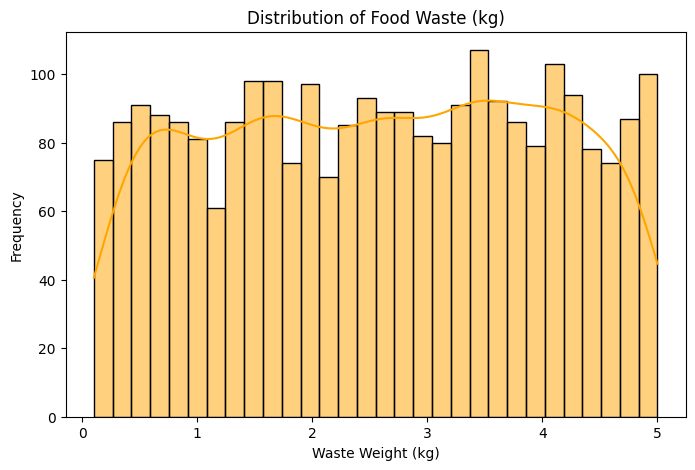

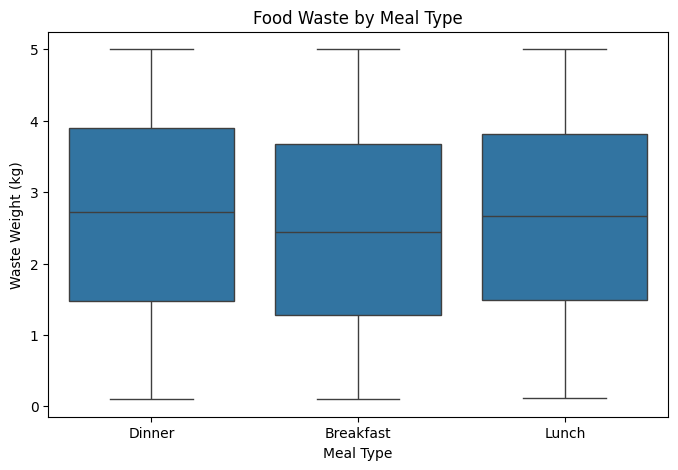

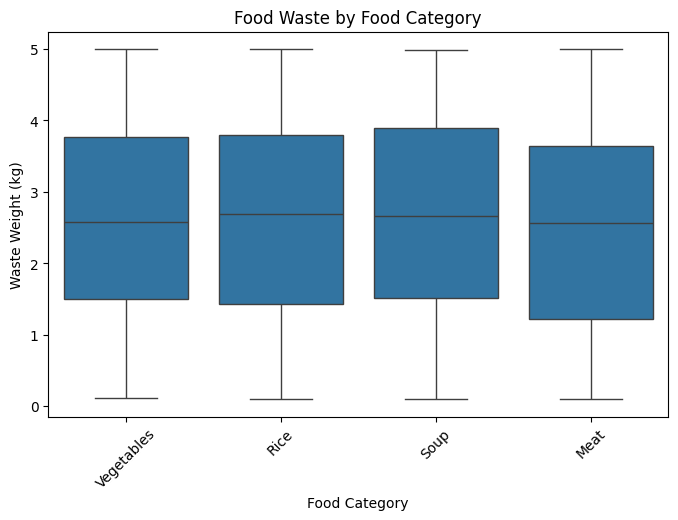

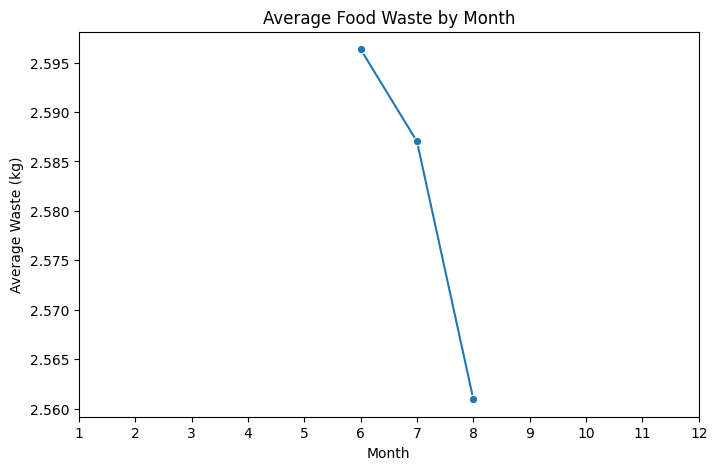

In [6]:
# Step 4: Exploratory Data Analysis - Visualize the data

# 4a) Distribution of Waste Weight (our target variable)
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Waste_Weight_kg'], bins=30, kde=True, color='orange')
plt.title('Distribution of Food Waste (kg)')
plt.xlabel('Waste Weight (kg)')
plt.ylabel('Frequency')
plt.show()

# 4b) Waste by Meal Type
plt.figure(figsize=(8, 5))
sns.boxplot(x='Meal', y='Waste_Weight_kg', data=df_clean)
plt.title('Food Waste by Meal Type')
plt.xlabel('Meal Type')
plt.ylabel('Waste Weight (kg)')
plt.show()

# 4c) Waste by Food Category
plt.figure(figsize=(8, 5))
sns.boxplot(x='Food_Category', y='Waste_Weight_kg', data=df_clean)
plt.title('Food Waste by Food Category')
plt.xlabel('Food Category')
plt.ylabel('Waste Weight (kg)')
plt.xticks(rotation=45)  # rotate x-axis labels for better readability
plt.show()

# 4d) Average waste by month
plt.figure(figsize=(8, 5))
monthly_waste = df_clean.groupby('Month')['Waste_Weight_kg'].mean()
sns.lineplot(x=monthly_waste.index, y=monthly_waste.values, marker='o')
plt.title('Average Food Waste by Month')
plt.xlabel('Month')
plt.ylabel('Average Waste (kg)')
plt.xticks(range(1, 13))
plt.show()


## STEP 5: Feature Engineering & Prepare for Modeling

We convert categorical (text) columns to numbers using One-Hot Encoding, then split data into training and testing sets.


In [7]:
# Step 5: Feature Engineering

# 5a) Define target variable (what we want to predict)
target_column = 'Waste_Weight_kg'
y = df_clean[target_column]  # the waste amount

# 5b) Define features (everything except target and original date)
feature_columns = [col for col in df_clean.columns if col not in [target_column, 'Date', 'Cost_Loss']]
X = df_clean[feature_columns]

print("Features:", feature_columns)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# 5c) One-Hot Encoding: Convert text columns to numbers
# This is necessary because ML models can only work with numbers
categorical_columns = ['Meal', 'Canteen_Section', 'Food_Category']  # text columns
X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

print("\nAfter encoding - Feature matrix shape:", X_encoded.shape)
print("Encoded columns:", X_encoded.columns.tolist())

# 5d) Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("\nTraining set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Features: ['Meal', 'Canteen_Section', 'Food_Category', 'Unit_Price_per_kg', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend']
Feature matrix shape: (2600, 9)
Target shape: (2600,)

After encoding - Feature matrix shape: (2600, 14)
Encoded columns: ['Unit_Price_per_kg', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Meal_Dinner', 'Meal_Lunch', 'Canteen_Section_B', 'Canteen_Section_C', 'Canteen_Section_D', 'Food_Category_Rice', 'Food_Category_Soup', 'Food_Category_Vegetables']

Training set size: 2080
Testing set size: 520


## STEP 6: Train and Compare Models

We train three different models and compare their performance:
1. **Linear Regression** - Simple baseline model (assumes linear relationship)
2. **Decision Tree** - Can capture non-linear patterns
3. **Random Forest** - Ensemble of many trees (usually best performance)


In [8]:
# Step 6: Train and Evaluate Models

# 6a) Define a helper function to train and evaluate a model
def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name):
    # Train the model on training data
    model.fit(X_train, y_train)
    
    # Make predictions on test data
    predictions = model.predict(X_test)
    
    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, predictions)  # Mean Absolute Error
    rmse = np.sqrt(mean_squared_error(y_test, predictions))  # Root Mean Squared Error
    r2 = r2_score(y_test, predictions)  # R-squared (explained variance)
    
    # Print results
    print(f"\n{model_name} Results:")
    print(f"  MAE  (Mean Absolute Error): {mae:.4f} kg")
    print(f"  RMSE (Root Mean Squared Error): {rmse:.4f} kg")
    print(f"  R²   (R-squared Score): {r2:.4f}")
    
    return model, mae, rmse, r2

# 6b) Model 1: Linear Regression with Scaling
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # scale features to have mean=0, std=1
    ('lr', LinearRegression())
])
lr_model, lr_mae, lr_rmse, lr_r2 = train_and_evaluate(
    lr_pipeline, X_train, y_train, X_test, y_test, "Linear Regression"
)

# 6c) Model 2: Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)  # random_state for reproducibility
dt_model, dt_mae, dt_rmse, dt_r2 = train_and_evaluate(
    dt_model, X_train, y_train, X_test, y_test, "Decision Tree"
)

# 6d) Model 3: Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,  # number of trees
    random_state=42,
    n_jobs=-1  # use all CPU cores
)
rf_model, rf_mae, rf_rmse, rf_r2 = train_and_evaluate(
    rf_model, X_train, y_train, X_test, y_test, "Random Forest"
)



Linear Regression Results:
  MAE  (Mean Absolute Error): 1.2564 kg
  RMSE (Root Mean Squared Error): 1.4522 kg
  R²   (R-squared Score): 0.0103

Decision Tree Results:
  MAE  (Mean Absolute Error): 1.6535 kg
  RMSE (Root Mean Squared Error): 2.0346 kg
  R²   (R-squared Score): -0.9424

Random Forest Results:
  MAE  (Mean Absolute Error): 1.3202 kg
  RMSE (Root Mean Squared Error): 1.5490 kg
  R²   (R-squared Score): -0.1259


## STEP 7: Compare All Models

Let's see which model performed best and visualize the results.


MODEL COMPARISON RESULTS


,Model,MAE (kg),RMSE (kg),R² Score
0,Linear Regression,1.256362,1.452238,0.010341
1,Decision Tree,1.653538,2.034550,-0.942436
2,Random Forest,1.320210,1.548975,-0.125897



🏆 Best Model: Linear Regression


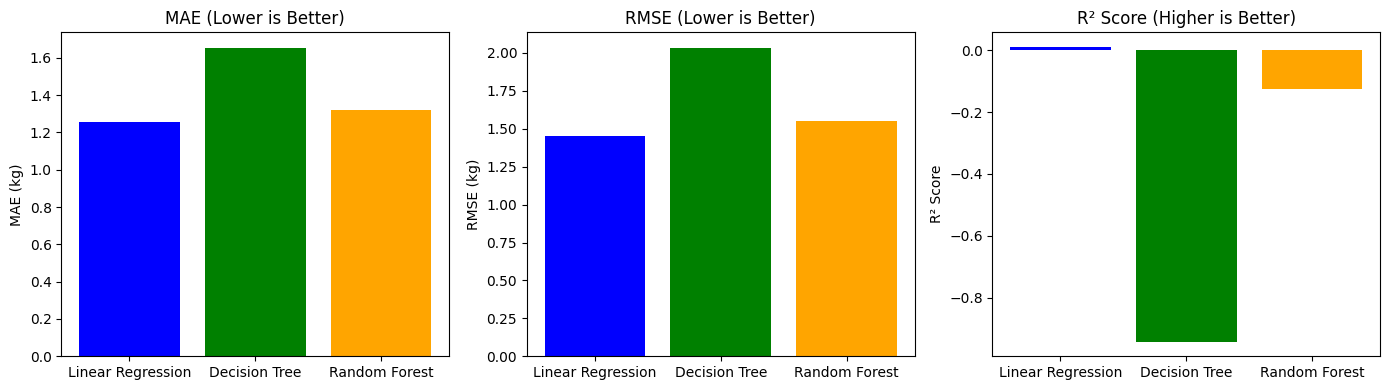

In [9]:
# Step 7: Compare Model Performance

# Create a summary table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE (kg)': [lr_mae, dt_mae, rf_mae],
    'RMSE (kg)': [lr_rmse, dt_rmse, rf_rmse],
    'R² Score': [lr_r2, dt_r2, rf_r2]
})

print("=" * 60)
print("MODEL COMPARISON RESULTS")
print("=" * 60)
display(results)

# Find best model based on R² score
best_idx = results['R² Score'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
print(f"\n🏆 Best Model: {best_model_name}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# MAE comparison
axes[0].bar(results['Model'], results['MAE (kg)'], color=['blue', 'green', 'orange'])
axes[0].set_title('MAE (Lower is Better)')
axes[0].set_ylabel('MAE (kg)')

# RMSE comparison
axes[1].bar(results['Model'], results['RMSE (kg)'], color=['blue', 'green', 'orange'])
axes[1].set_title('RMSE (Lower is Better)')
axes[1].set_ylabel('RMSE (kg)')

# R² comparison
axes[2].bar(results['Model'], results['R² Score'], color=['blue', 'green', 'orange'])
axes[2].set_title('R² Score (Higher is Better)')
axes[2].set_ylabel('R² Score')

plt.tight_layout()
plt.show()


## STEP 8: Visualize Predictions vs Actual

Let's see how well our best model predicts waste compared to actual waste values.


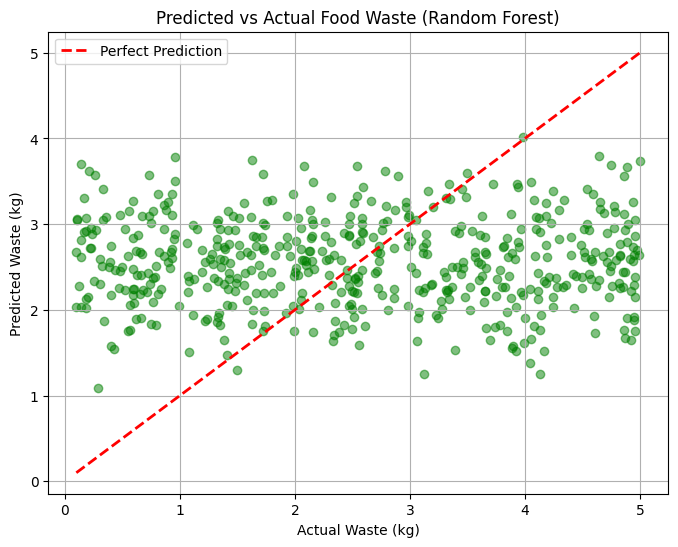

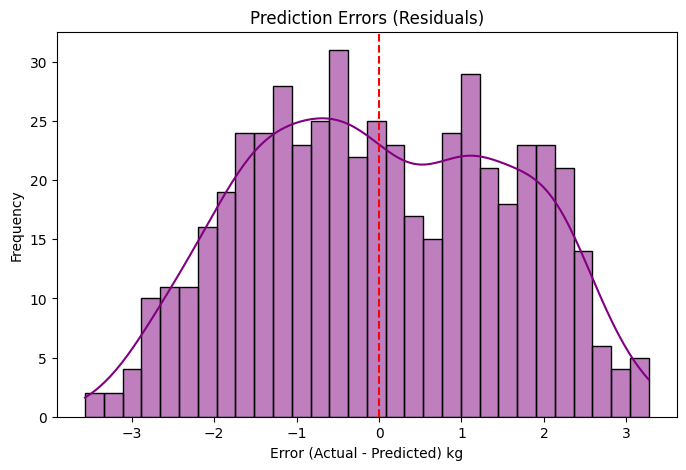

In [10]:
# Step 8: Visualize Predictions vs Actual Values

# Use Random Forest (usually best) to make predictions
rf_model.fit(X_train, y_train)  # train the model
y_pred = rf_model.predict(X_test)  # predict on test data

# Create scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Waste (kg)')
plt.ylabel('Predicted Waste (kg)')
plt.title('Predicted vs Actual Food Waste (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

# Residual plot (difference between actual and predicted)
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.title('Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted) kg')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()


## STEP 9: Feature Importance

Let's see which features are most important for predicting food waste.


Top 10 Most Important Features:
               Feature  Importance
3                  Day    0.256428
4            DayOfWeek    0.130496
7           Meal_Lunch    0.078236
0    Unit_Price_per_kg    0.076055
6          Meal_Dinner    0.073086
9    Canteen_Section_C    0.071752
8    Canteen_Section_B    0.071056
10   Canteen_Section_D    0.068886
2                Month    0.059913
11  Food_Category_Rice    0.037963


C:\Users\Srevarshan\AppData\Local\Temp\ipykernel_2852\926152799.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')


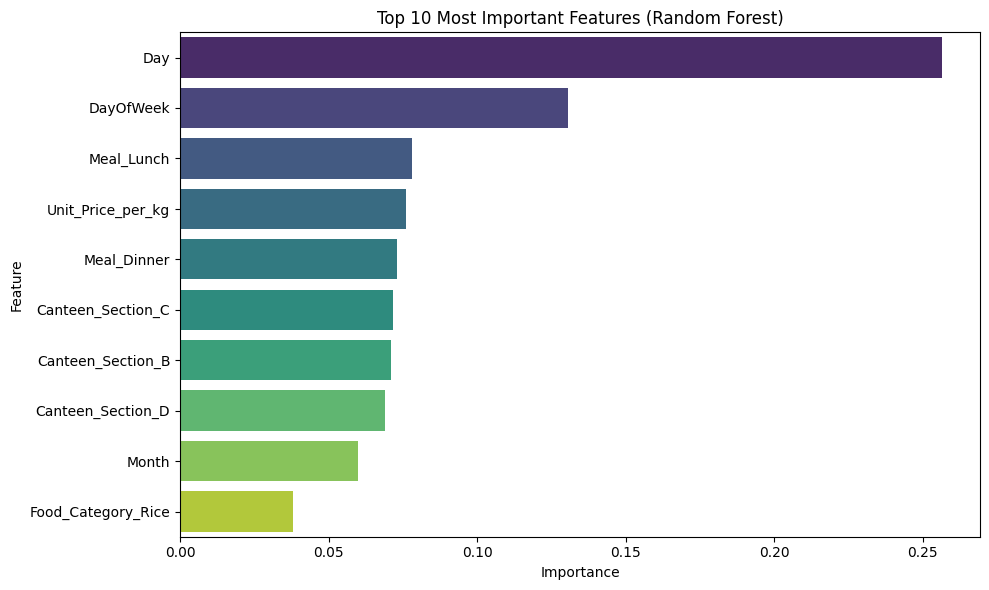

In [11]:
# Step 9: Feature Importance Analysis

# Get feature importances from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize top 10 features
plt.figure(figsize=(10, 6))
top_10 = feature_importance.head(10)
sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## STEP 10: Save the Best Model

We save the trained model so we can use it later to make predictions on new data.


In [ ]:
# Step 10: Save the Model

import os  # for creating folders

# Create outputs folder if it doesn't exist
os.makedirs('outputs', exist_ok=True)

# Save the Random Forest model
model_path = 'outputs/food_waste_model.joblib'
joblib.dump(rf_model, model_path)
print(f"✅ Model saved to: {model_path}")

# Also save the feature names for later use
feature_names_path = 'outputs/feature_names.joblib'
joblib.dump(X_encoded.columns.tolist(), feature_names_path)
print(f"✅ Feature names saved to: {feature_names_path}")

# Print summary
print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"Dataset: University Canteen Food Waste")
print(f"Total samples: {len(df_clean)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Best Model: Random Forest")
print(f"Best R² Score: {rf_r2:.4f}")
print(f"Best MAE: {rf_mae:.4f} kg")
print("=" * 60)


## 🎉 Final Notes

Congratulations! You have completed an end-to-end machine learning project!

### What We Did:
1. ✅ Loaded and explored the food waste dataset
2. ✅ Cleaned the data (handled missing values, duplicates)
3. ✅ Performed Exploratory Data Analysis (EDA) with visualizations
4. ✅ Engineered features (converted text to numbers, extracted time features)
5. ✅ Trained 3 different models (Linear Regression, Decision Tree, Random Forest)
6. ✅ Compared model performance using MAE, RMSE, and R²
7. ✅ Visualized predictions vs actual values
8. ✅ Analyzed feature importance
9. ✅ Saved the best model for future use

### How Restaurants Can Use This Model:
- **Predict daily waste** based on meal type, food category, and other factors
- **Plan better**: Order less food on days with predicted high waste
- **Save money**: Reduce food waste = reduce cost loss
- **Help environment**: Less food waste = better sustainability

### Possible Improvements:
- Try more advanced models (XGBoost, Gradient Boosting)
- Hyperparameter tuning
- Add more features (weather, holidays, special events)
- Deploy as a web app for real-time predictions
